In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.decomposition import PCA

In [2]:
import pandas as pd
df = pd.read_csv('../data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


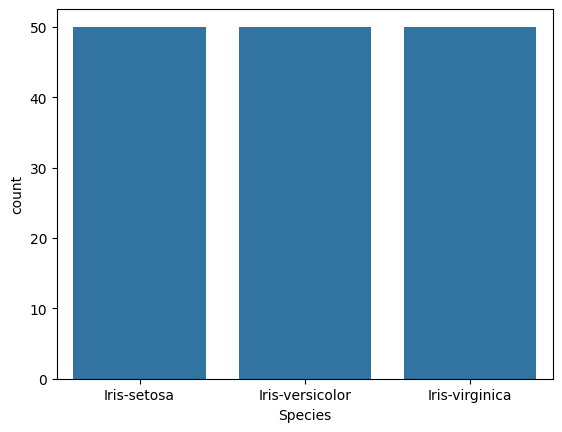

In [6]:
sns.countplot(x='Species', data=df)
plt.show()

In [7]:
X= df.drop(["Id","Species"], axis=1)

In [8]:
le = LabelEncoder()
df['SpeciesEncoded'] = le.fit_transform(df['Species'])

In [9]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


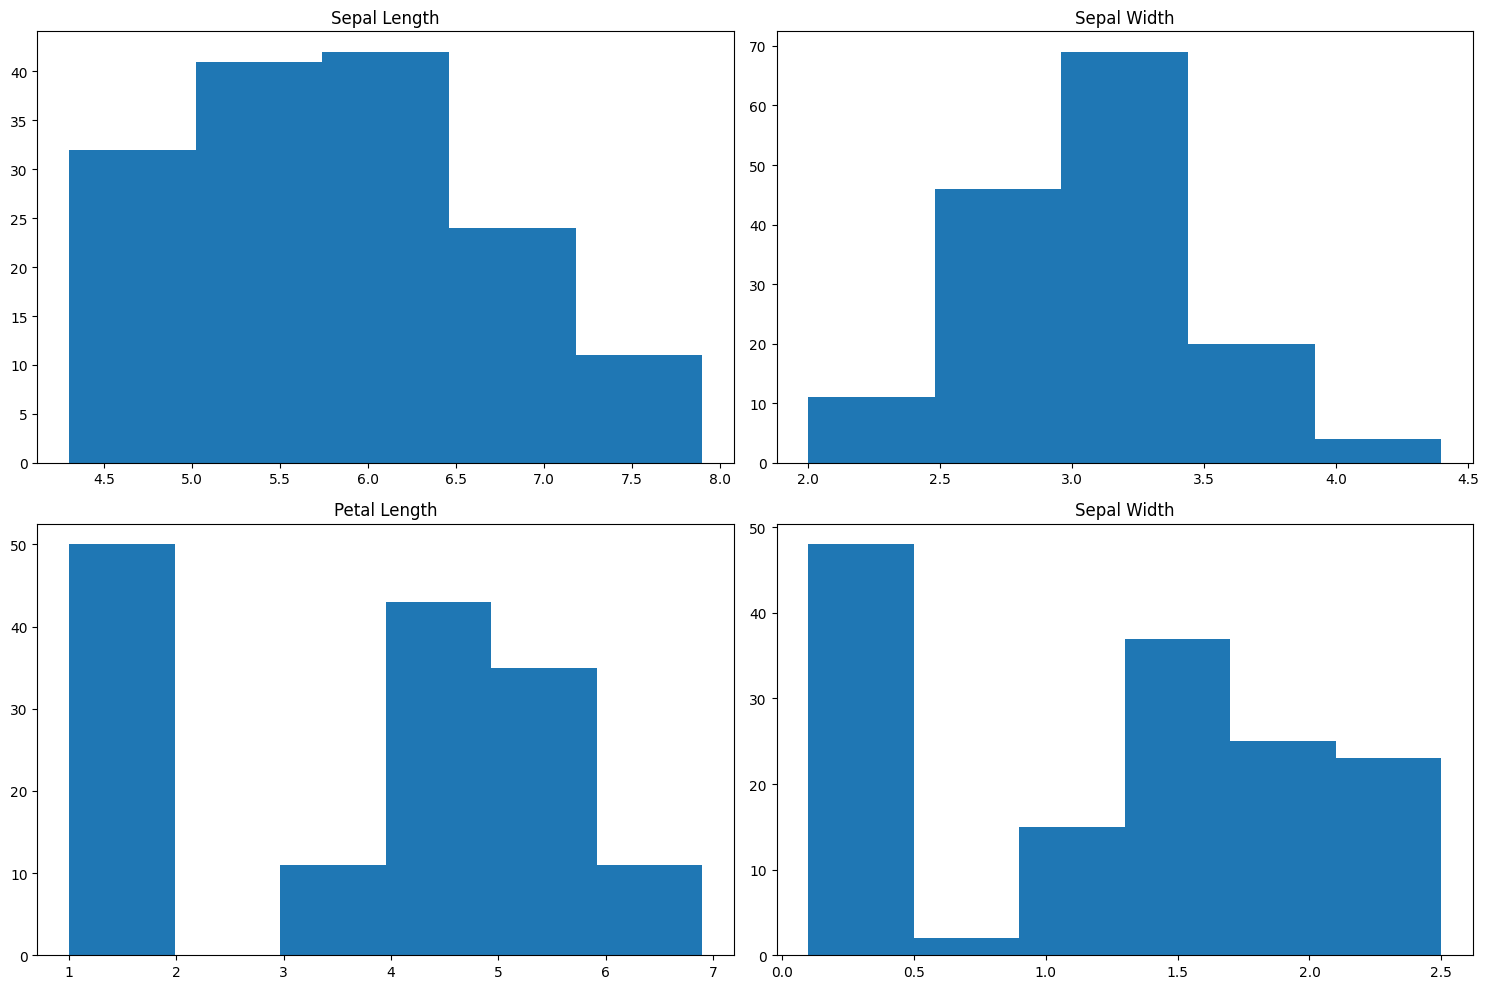

In [10]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

#Histogram 1: Sepal Length
axes[0,0].set_title("Sepal Length")
axes[0,0].hist(X['SepalLengthCm'], bins=5)

#Histogram 1: Sepal Length
axes[0,1].set_title("Sepal Width")
axes[0,1].hist(X['SepalWidthCm'], bins=5)

#Histogram 1: Sepal Length
axes[1,0].set_title("Petal Length")
axes[1,0].hist(X['PetalLengthCm'], bins=6)

#Histogram 1: Sepal Length
axes[1,1].set_title("Sepal Width")
axes[1,1].hist(X['PetalWidthCm'], bins=6)

plt.tight_layout()
plt.show()

In [11]:
scaler = StandardScaler()

X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalLengthCm']]

x = scaler.fit_transform(X)
x[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.3412724 ],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.3412724 ],
       [-1.38535265,  0.33784833, -1.39813811, -1.39813811],
       [-1.50652052,  0.10644536, -1.2844067 , -1.2844067 ],
       [-1.02184904,  1.26346019, -1.3412724 , -1.3412724 ]])

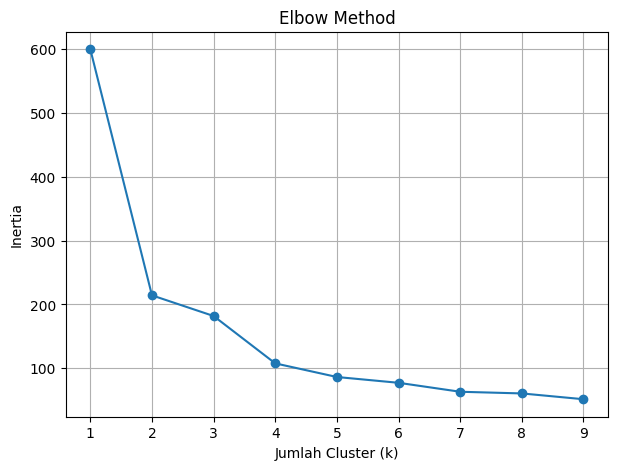

In [12]:
inertia_list = []
K_range = range(1,10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

In [14]:
kmeans.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [15]:
labels = kmeans.predict(x)

In [16]:
df['Cluster'] = labels

In [17]:
print('Cluster ditemukan:',df['Cluster'].unique())

Cluster ditemukan: [2 1 0]


In [18]:
sil_score = silhouette_score(x, df['Cluster'])
print("\n===== SILHOUETTE SCORE =====")
print('Silhouette Score:', sil_score)


===== SILHOUETTE SCORE =====
Silhouette Score: 0.49861226565132405


In [19]:
print('\n===== CONFUSION MATRIX =====')
cm = confusion_matrix(df["SpeciesEncoded"], df["Cluster"])
print(cm)


===== CONFUSION MATRIX =====
[[ 0 18 32]
 [46  4  0]
 [50  0  0]]


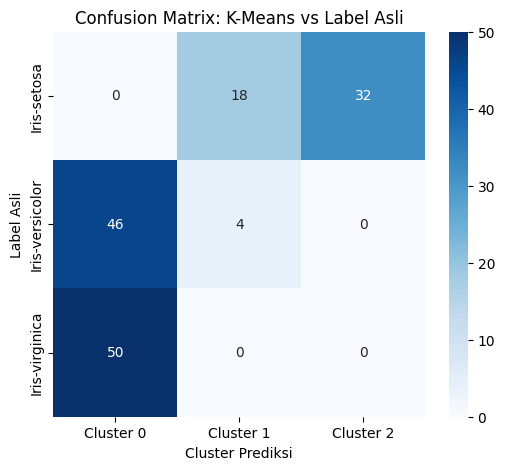

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Cluster 0", "Cluster 1", "Cluster 2"],
    yticklabels=le.classes_
)
plt.title("Confusion Matrix: K-Means vs Label Asli")
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Asli")
plt.show()

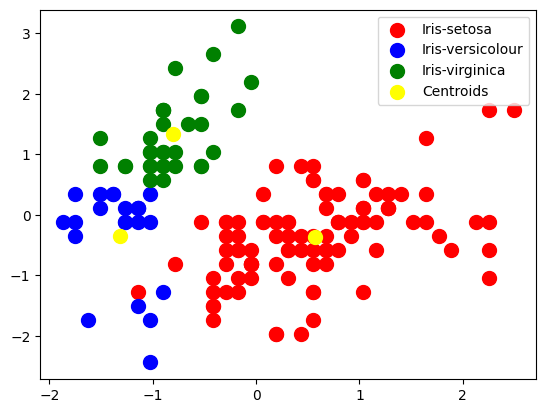

In [21]:
#visualising the clusters
plt.scatter(x[df["Cluster"] == 0, 0], x[df["Cluster"] == 0, 1], s = 100, c = 'red', label = 'Iris-setosa')
plt.scatter(x[df["Cluster"] == 1, 0], x[df["Cluster"] == 1, 1], s = 100, c = 'blue', label = 'Iris-versicolour')
plt.scatter(x[df["Cluster"] == 2, 0], x[df["Cluster"] == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')

plt.legend()

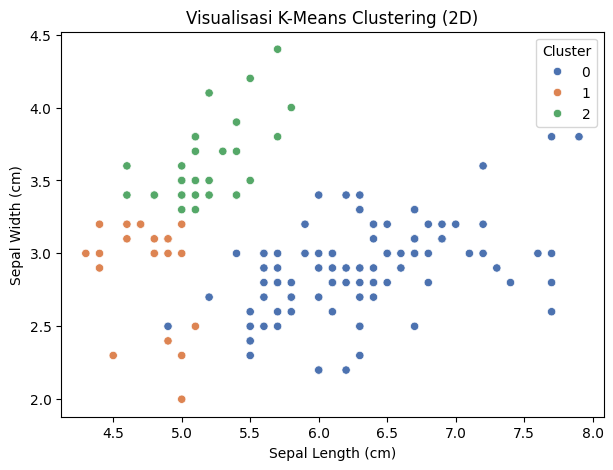

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["SepalLengthCm"],
    y=df["SepalWidthCm"],
    hue=df["Cluster"],
    palette="deep"
)
plt.title("Visualisasi K-Means Clustering (2D)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

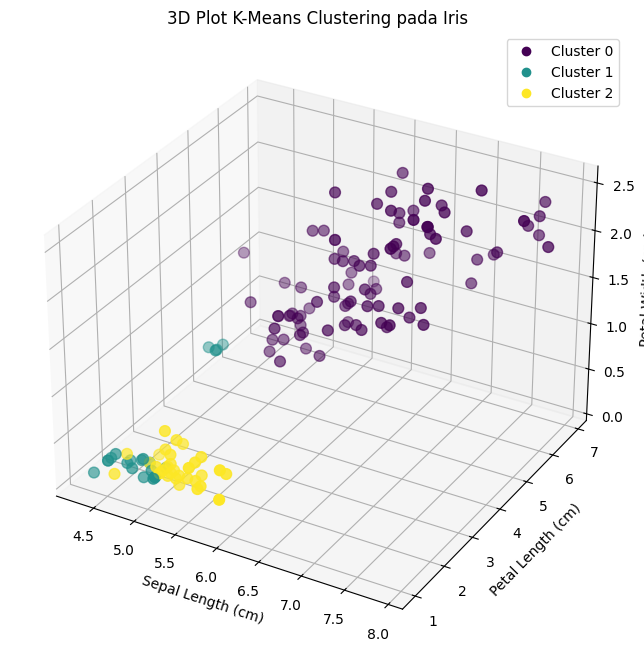

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df["SepalLengthCm"],
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    c=df["Cluster"],
    s = 60
)
ax.set_title("3D Plot K-Means Clustering pada Iris")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.set_zlabel("Petal Width (cm)")
#Legend cluster
legend_labels = [f"Cluster {i}" for i in range(3)]
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)
plt.show()